<a href="https://colab.research.google.com/github/DSLmpv/Laboratorio-de-Python---Trabajo-practico-integrador/blob/main/Lopez_Uria_TP1_LabProgrPythonR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Laboratorio de Programacion en Python y R**
## Trabajo Práctico Integrador — Módulo Python
**Maestria en Econometria — Universidad Torcuato Di Tella**  
Docente: Ian Evangelos Bounos | Año 2026

Alumnos: Diego S. López & Sebastián Uria M.

---
# Parte 1 — Robustez ante contaminación de muestras

##1.1 Estimadores de tendencia central

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize
sns.set_theme(style='whitegrid')
np.random.seed(42)

In [ ]:
#Generamos las muestras
mu_ver      = 10.0
sigma_ver   = 3.0
M           = 1000
n           = 500

print(f'Media:{mu_ver}, Sigma:{sigma_ver}^2')


#Contaminación con p ∈ {0 %,5 %,10 %,20 %}
mu_cont     = 23.0
sigma_cont  = 8.0

print(f'Media cont.:{mu_cont}, Sigma cont.:{sigma_cont}^2')

proporciones = [0.0, 0.05, 0.1, 0.2]
resultados = {}

for p in proporciones:
    n_outliers = int(n * p)
    media     = np.empty(M)
    mediana   = np.empty(M)

    for m in range(M):
        muestra = np.random.normal(mu_ver, sigma_ver, size=n)
        idx_out = np.random.choice(n, n_outliers, replace=False)
        muestra[idx_out] = np.random.normal(mu_cont, sigma_cont, n_outliers)
        media[m]   = np.mean(muestra)
        mediana[m] = np.median(muestra)

    resultados[p] = {'n_out': n_outliers, 'medias': media, 'medianas': mediana}


print(f'\n{"Contam.":>7} {"Media":>10} {"Sesgo":>8} {"ECM":>9} {"Mediana":>12} {"Sesgo":>8} {"ECM":>9}')
print('-' * 70)
for p, r in resultados.items():
    em, emd   = r['medias'].mean(), r['medianas'].mean()
    sesgo_mu  = em  - mu_ver
    sesgo_md  = emd - mu_ver
    ecm_mu    = np.mean((r['medias']   - mu_ver) ** 2)
    ecm_md    = np.mean((r['medianas'] - mu_ver) ** 2)
    print(f'{p*100:>6.0f}% {em:>10.3f} {sesgo_mu:>8.3f} {ecm_mu:>9.3f} '
          f'{emd:>12.3f} {sesgo_md:>8.3f} {ecm_md:>9.3f}')


Media:10.0, Sigma:3.0^2
Media cont.:23.0, Sigma cont.:8.0^2

Contam.      Media    Sesgo       ECM      Mediana    Sesgo       ECM
----------------------------------------------------------------------
     0%     10.003    0.003     0.019       10.004    0.004     0.028
     5%     10.646    0.646     0.440       10.177    0.177     0.060
    10%     11.301    1.301     1.721       10.371    0.371     0.171
    20%     12.591    2.591     6.752       10.825    0.825     0.716


> Al comparar el desempeño de los estimadores de localización, bajo normalidad estricta la media muestral ofrece el menor ECM al ser el estimador insesgado más eficiente. Sin embargo, **a partir del primer nivel de contaminación (5%)**, la mediana supera a la media con un menor ECM, tendencia que se profundiza a medida que aumenta la contaminación. Estos resultados se corresponden a lo analizado en la clase 3.


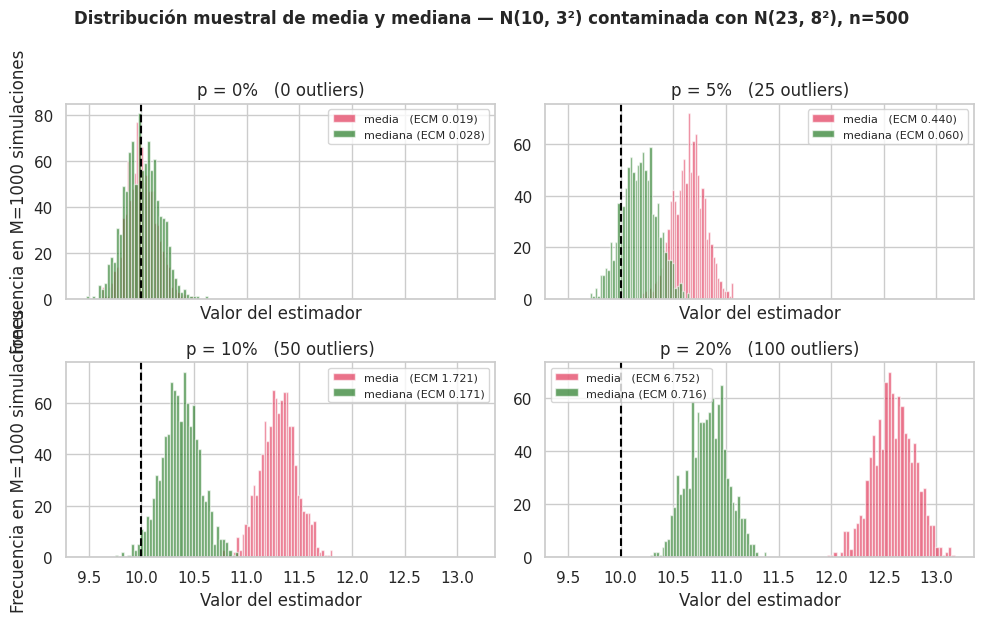

In [ ]:
#Gráfico de distribución de media y mediana para cada p de contaminación
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)

for ax, (p, r) in zip(axes.flat, resultados.items()):
    ecm_mu = np.mean((r['medias']   - mu_ver) ** 2)
    ecm_md = np.mean((r['medianas'] - mu_ver) ** 2)

    ax.hist(r['medias'],   bins=40, alpha=0.6, color='crimson',
            label=f'media   (ECM {ecm_mu:.3f})')
    ax.hist(r['medianas'], bins=40, alpha=0.6, color='darkgreen',
            label=f'mediana (ECM {ecm_md:.3f})')
    ax.axvline(mu_ver, color='black', ls='--', lw=1.5)

    ax.set_title(f'p = {p:.0%}   ({r["n_out"]} outliers)')
    ax.set_xlabel('Valor del estimador')
    ax.legend(fontsize=8)

for ax in axes[:, 0]:
    ax.set_ylabel(f'Frecuencia en M={M} simulaciones')
    fig.suptitle(f'Distribución muestral de media y mediana — '
             f'N({mu_ver:.0f}, {sigma_ver:.0f}²) contaminada con '
             f'N({mu_cont:.0f}, {sigma_cont:.0f}²), n={n}', y=1.03,
                 fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

> Podemos apreciar cómo los estimadores se alejan del valor real de μ conforme aumenta la cantidad de valores atípicos en las muestras, pero también que la media se separa más que la mediana.


##1.2 Regresión lineal bajo contaminación

In [ ]:
# ── PARÁMETROS ───────────────────────────────────────────────────────────────
# Modelo verdadero: y = 2 + 5x + e
n            = 500
M            = 500
beta0_true, beta1_true = 2.0, 5.0

# ── ESTIMADORES ──────────────────────────────────────────────────────────────
def ols_manual(y, X):
    return np.linalg.solve(X.T @ X, X.T @ y)

def costo_lad(beta, y, X):
    return np.sum(np.abs(y - X @ beta))

def lad(y, X, beta_inicial=None):
    if beta_inicial is None:
        beta_inicial = ols_manual(y, X)
    res = minimize(costo_lad, beta_inicial, args=(y, X), method='Nelder-Mead')
    return res.x

# ── SIMULACIONES ─────────────────────────────────────────────────────────────
resultados = {p: {'ols': np.empty(M), 'lad': np.empty(M)} for p in proporciones}

for p in proporciones:
    for m in range(M):
        # Muestra limpia
        x_raw = np.random.uniform(0, 10, size=n)
        eps   = np.random.normal(0, 1.5, size=n)
        y_lim = beta0_true + beta1_true * x_raw + eps

        # Contaminación en 4 niveles
        n_outliers = int(n * p)
        x_cont = x_raw.copy()
        y_cont = y_lim.copy()
        if n_outliers > 0:
            idx_out = np.random.choice(n, n_outliers, replace=False)
            y_cont[idx_out] += np.random.uniform(15, 25, n_outliers)
            x_cont[idx_out] += np.random.uniform(15, 25, n_outliers)

        # OLS manual y LDA sobre muestra contaminada
        X_mat = np.column_stack([np.ones(n), x_cont])
        beta_ols = ols_manual(y_cont, X_mat)
        beta_lad = lad(y_cont, X_mat, beta_inicial=beta_ols)

        resultados[p]['ols'][m] = beta_ols[1]
        resultados[p]['lad'][m] = beta_lad[1]

# ── TABLA COMPARATIVA ────────────────────────────────────────────────────────
print(f'{"Contaminacion":<15} {"Estimador":<12} {"beta1_est":>12} {"Sesgo":>12} {"ECM":>12}'
      f'  | Verdadero: b1={beta1_true}')
print('-' * 68)

for p in proporciones:
    etiqueta = f'{int(p*100)}%'
    for nombre, clave in [('OLS', 'ols'), ('LAD', 'lad')]:
        est   = resultados[p][clave]
        sesgo = est.mean() - beta1_true
        ecm   = np.mean((est - beta1_true)**2)
        print(f'{etiqueta:<15} {nombre:<12} {est.mean():>12.4f} {sesgo:>12.4f} {ecm:>12.4f}')
        etiqueta = ''
    print()

Contaminacion   Estimador       beta1_est        Sesgo          ECM  | Verdadero: b1=5.0
--------------------------------------------------------------------
0%              OLS                5.0015       0.0015       0.0005
                LAD                5.0019       0.0019       0.0008

5%              OLS                2.1756      -2.8244       7.9849
                LAD                4.7433      -0.2567       0.0673

10%             OLS                1.7210      -3.2790      10.7562
                LAD                3.9592      -1.0408       1.2005

20%             OLS                1.4242      -3.5758      12.7892
                LAD                1.5673      -3.4327      11.7883



In [ ]:
# REV1── PARÁMETROS ───────────────────────────────────────────────────────────────
# Modelo verdadero: y = 2 + 5x + e
n            = 500
M            = 500
beta0_true, beta1_true = 2.0, 5.0

# ── ESTIMADORES ──────────────────────────────────────────────────────────────
def ols_manual(y, X):
    return np.linalg.solve(X.T @ X, X.T @ y)

def costo_lad(beta, y, X):
    return np.sum(np.abs(y - X @ beta))

def lad(y, X, beta_inicial=None):
    if beta_inicial is None:
        beta_inicial = ols_manual(y, X)
    res = minimize(costo_lad, beta_inicial, args=(y, X), method='Nelder-Mead')
    return res.x

# ── SIMULACIONES ─────────────────────────────────────────────────────────────
resultados = {p: {'ols': np.empty(M), 'lad': np.empty(M)} for p in proporciones}

for p in proporciones:
    for m in range(M):
        # Muestra limpia
        x_raw = np.random.uniform(0, 10, size=n)
        eps   = np.random.normal(0, 1.5, size=n)
        y_lim = beta0_true + beta1_true * x_raw + eps

        # Contaminación en 4 niveles
        n_outliers = int(n * p)
        y_cont = y_lim.copy()
        if n_outliers > 0:
            idx_out = np.random.choice(n, n_outliers, replace=False)
            y_cont[idx_out] += np.random.normal(mu_cont, sigma_cont, n_outliers)

        # OLS manual y LDA sobre muestra contaminada
        X_mat = np.column_stack([np.ones(n), x_raw])
        beta_ols = ols_manual(y_cont, X_mat)
        beta_lad = lad(y_cont, X_mat, beta_inicial=beta_ols)

        resultados[p]['ols'][m] = beta_ols[1]
        resultados[p]['lad'][m] = beta_lad[1]

# ── TABLA COMPARATIVA ────────────────────────────────────────────────────────
print(f'{"Contaminacion":<15} {"Estimador":<12} {"beta1_est":>12} {"Sesgo":>12} {"ECM":>12}'
      f'  | Verdadero: b1={beta1_true}')
print('-' * 68)

for p in proporciones:
    etiqueta = f'{int(p*100)}%'
    for nombre, clave in [('OLS', 'ols'), ('LAD', 'lad')]:
        est   = resultados[p][clave]
        sesgo = est.mean() - beta1_true
        ecm   = np.mean((est - beta1_true)**2)
        print(f'{etiqueta:<15} {nombre:<12} {est.mean():>12.4f} {sesgo:>12.4f} {ecm:>12.4f}')
        etiqueta = ''
    print()

Contaminacion   Estimador       beta1_est        Sesgo          ECM  | Verdadero: b1=5.0
--------------------------------------------------------------------
0%              OLS                4.9994      -0.0006       0.0006
                LAD                4.9990      -0.0010       0.0009

5%              OLS                5.0084       0.0084       0.0074
                LAD                5.0015       0.0015       0.0009

10%             OLS                4.9986      -0.0014       0.0123
                LAD                4.9993      -0.0007       0.0010

20%             OLS                4.9892      -0.0108       0.0249
                LAD                4.9946      -0.0054       0.0014



>En ausencia de contaminación, el estimador OLS (MCO) resulta superior al presentar menor ECM que LAD. Esto resulta consistente con el Teorema de Gauss-Markov, según el cual OLS es el Estimador Lineal Insesgado de Mínima Varianza. Sin embargo, **ante la presencia de contaminación, LAD demuestra una notable capacidad de resistencia, manteniendo un sesgo y ECM sustancialmente menores que OLS**, actuando como una mediana condicional y reduciendo el impacto de las observaciones extremas.

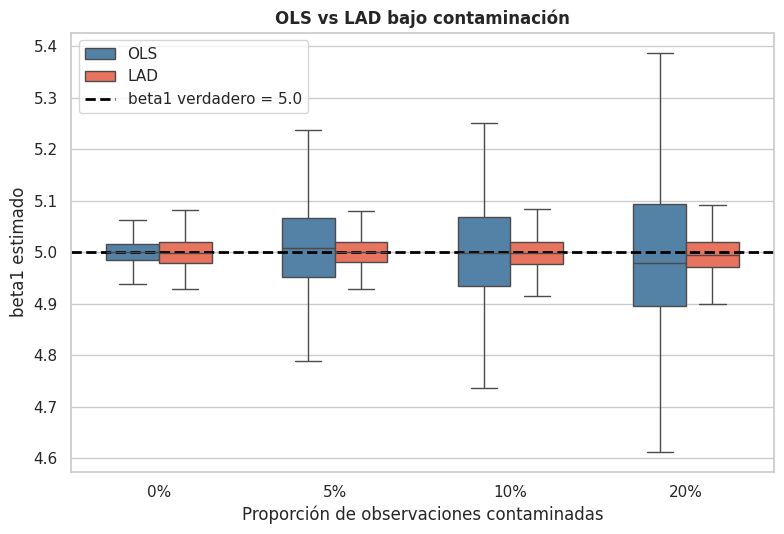

In [ ]:
# ── GRÁFICO: boxplots con ambos estimadores lado a lado ──────────────────────
df_est = pd.DataFrame([
    {'beta1': v, 'Contaminacion': f'{int(p*100)}%', 'Estimador': nombre}
    for p in proporciones
    for nombre, clave in [('OLS', 'ols'), ('LAD', 'lad')]
    for v in resultados[p][clave]
])

plt.figure(figsize=(8, 5.5))
sns.boxplot(data=df_est, x='Contaminacion', y='beta1', hue='Estimador',
            palette=['steelblue', 'tomato'], showfliers=False, width=0.6)
plt.axhline(beta1_true, color='black', ls='--', lw=2,
            label=f'beta1 verdadero = {beta1_true}')
plt.title('OLS vs LAD bajo contaminación', fontweight='bold')
plt.xlabel('Proporción de observaciones contaminadas')
plt.ylabel('beta1 estimado')
plt.legend(loc='best')
plt.tight_layout(); plt.show()

>

---
# Parte 2 — Paradoja de Simpson y variables omitidas

##2.1 Construcción del modelo

In [ ]:
# ── PARÁMETROS ──────────────────────────────────────────────────────────────
np.random.seed(21)
tamanios = [10, 50, 200, 500, 2000]  # Para demostrar que el sesgo por variable omitida no desaparece con muestras grandes.
M = 1000                             # cantidad de simulaciones por tamaño de muestra
c = 1.5                              # efecto de Z y W sobre Y

resultados1 = []

# ── SIMULACIONES ────────────────────────────────────────────────────────────
for n in tamanios:
    for m in range(M):
        x = np.random.normal(0, 1, size=n)
        z_continua = x + np.random.normal(0, 1, size=n)
        w_continua = x + np.random.normal(0, 1, size=n)
        z = pd.qcut(z_continua, 4, labels=[1, 2, 3, 4]).astype(int)
        w = pd.qcut(w_continua, 4, labels=[1, 2, 3, 4]).astype(int)
        eps = np.random.normal(0, 1, size=n)
        y = c * z - c * w + eps
        df = pd.DataFrame({'Y': y, 'X': x, 'Z': z, 'W': w})

        modelo_X   = sm.OLS(df['Y'], sm.add_constant(df['X'])).fit()
        modelo_XZ  = sm.OLS(df['Y'], sm.add_constant(df[['X', 'Z']])).fit()
        modelo_XW  = sm.OLS(df['Y'], sm.add_constant(df[['X', 'W']])).fit()

        resultados1.append({
            'n': n, 'sim': m,
            'coef_marginal': modelo_X.params['X'],   'p_marginal': modelo_X.pvalues['X'],
            'coef_XZ':       modelo_XZ.params['X'],  'p_XZ':       modelo_XZ.pvalues['X'],
            'coef_XW':       modelo_XW.params['X'],  'p_XW':       modelo_XW.pvalues['X'],
        })

res1 = pd.DataFrame(resultados1)

# ── TABLA RESUMEN: media, sd y tasa de rechazo por especificación y n ───────
resumen1 = res1.groupby('n').agg(
    media_marginal=('coef_marginal', 'mean'), sd_marginal=('coef_marginal', 'std'),
    rechazo_marginal=('p_marginal', lambda p: (p < 0.05).mean()),

    media_XZ=('coef_XZ', 'mean'), sd_XZ=('coef_XZ', 'std'),
    rechazo_XZ=('p_XZ', lambda p: (p < 0.05).mean()),

    media_XW=('coef_XW', 'mean'), sd_XW=('coef_XW', 'std'),
    rechazo_XW=('p_XW', lambda p: (p < 0.05).mean()),
).reset_index()

pd.set_option('display.float_format', lambda x: f'{x:.4f}')
print(resumen1)

      n  media_marginal  sd_marginal  rechazo_marginal  media_XZ  sd_XZ  \
0    10         -0.0175       0.7712            0.0170   -1.2153 0.9078   
1    50         -0.0126       0.2244            0.0040   -1.1167 0.3044   
2   200          0.0008       0.1056            0.0070   -1.0924 0.1398   
3   500          0.0040       0.0693            0.0080   -1.0758 0.0890   
4  2000          0.0006       0.0331            0.0040   -1.0789 0.0434   

   rechazo_XZ  media_XW  sd_XW  rechazo_XW  
0      0.2550    1.2393 0.9983      0.2440  
1      0.9270    1.1077 0.2947      0.9240  
2      1.0000    1.0902 0.1411      1.0000  
3      1.0000    1.0843 0.0868      1.0000  
4      1.0000    1.0787 0.0428      1.0000  


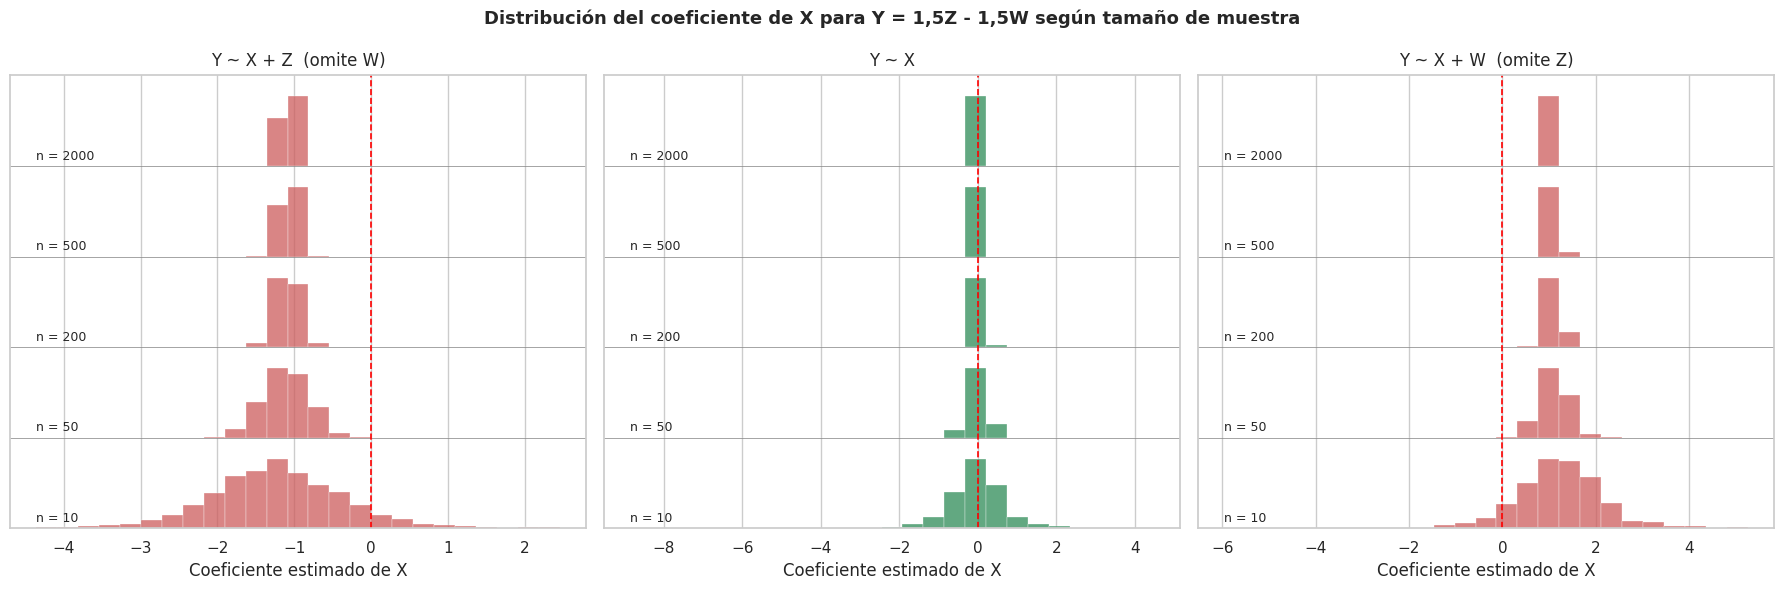

In [ ]:
def ridgeline_hist(res, col, titulo, ax=None, color='steelblue', bins=25):
    ns = sorted(res['n'].unique())
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # mismo rango de valores para todos los histogramas, así son comparables
    rango = (res[col].min(), res[col].max())
    separacion = 1.3  # distancia vertical entre histogramas

    for i, n in enumerate(ns):
        datos = res.loc[res['n'] == n, col]
        conteos, bordes = np.histogram(datos, bins=bins, range=rango)
        conteos_norm = conteos / conteos.max()  # normalizo altura para que todos se vean parecidos

        base = i * separacion
        centros = (bordes[:-1] + bordes[1:]) / 2
        ancho = bordes[1] - bordes[0]

        ax.bar(centros, conteos_norm, width=ancho, bottom=base,
               color=color, alpha=0.75, edgecolor='white', linewidth=0.3)
        ax.axhline(base, color='gray', linewidth=0.5)  # línea base de cada histograma
        ax.text(rango[0], base + 0.05, f"n = {n}", fontsize=9, va='bottom')

    ax.axvline(0, color='red', linestyle='--', linewidth=1.2)
    ax.set_yticks([])
    ax.set_xlabel('Coeficiente estimado de X')
    ax.set_title(titulo)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
ridgeline_hist(res1, 'coef_XZ',  'Y ~ X + Z  (omite W)', ax=axes[0], color='indianred')
ridgeline_hist(res1, 'coef_marginal', 'Y ~ X', ax=axes[1], color='seagreen')
ridgeline_hist(res1, 'coef_XW',  'Y ~ X + W  (omite Z)', ax=axes[2], color='indianred')

fig.suptitle('Distribución del coeficiente de X para Y = 1,5Z - 1,5W según tamaño de muestra', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

>Los histogramas permiten observar que el coeficiente estimado de X cambia según qué controles incorporemos al modelo, ya que Z lo vuelve negativo y W lo vuelve positivo. Además, se observa cómo se acota el desvío estandar a medida que aumenta la cantidad de observaciones.

##2.2 Ilustración de la paradoja

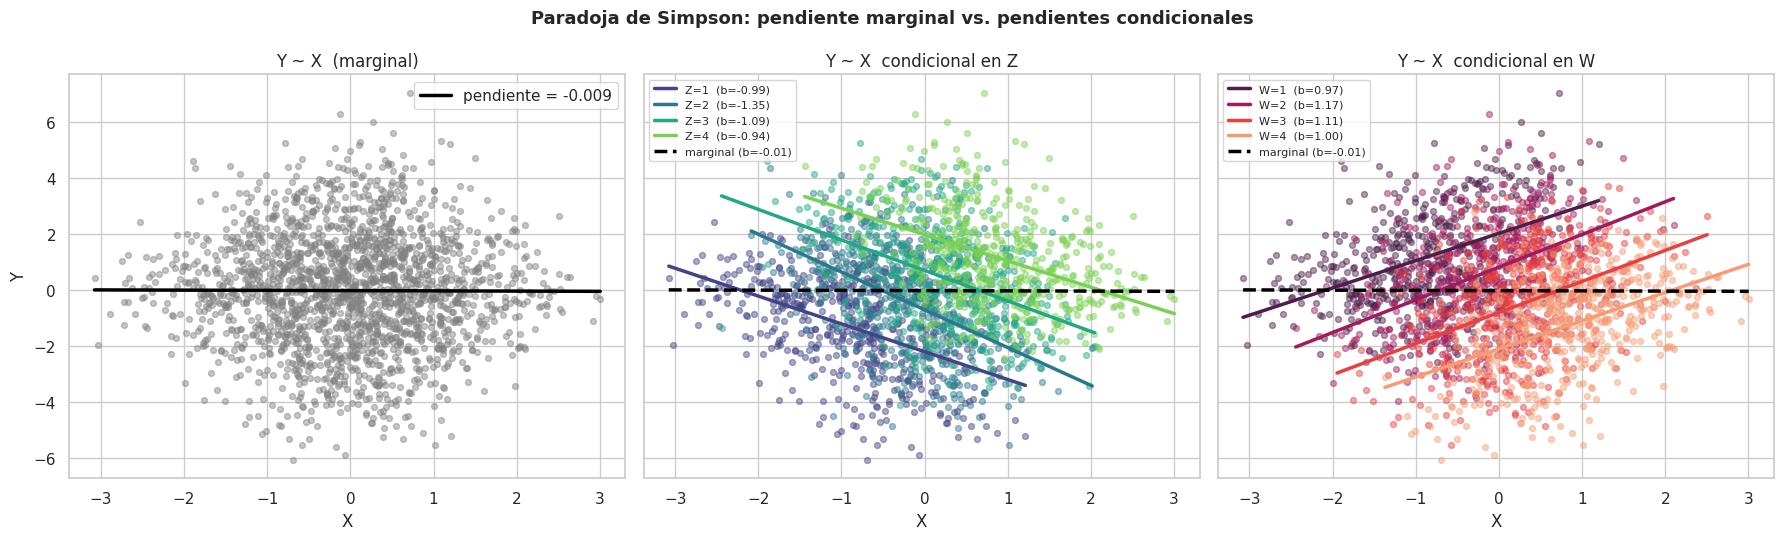

In [ ]:
# ── FUNCIÓN AUXILIAR: recta ajustada de un OLS simple ────────────────────────
def recta_ols(x, y, puntos=100):
    b = sm.OLS(y, sm.add_constant(x)).fit().params
    grilla = np.linspace(x.min(), x.max(), puntos)
    return grilla, b.iloc[0] + b.iloc[1] * grilla, b.iloc[1]

# ── GRÁFICO: marginal vs condicional por Z y por W ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)

# Panel 1: regresión marginal Y ~ X
gx, gy, pend = recta_ols(df['X'], df['Y'])
axes[0].scatter(df['X'], df['Y'], s=18, alpha=0.45, color='grey')
axes[0].plot(gx, gy, color='black', lw=2.5, label=f'pendiente = {pend:.3f}')
axes[0].set_title('Y ~ X  (marginal)')
axes[0].set_xlabel('X'); axes[0].set_ylabel('Y'); axes[0].legend()

# Paneles 2 y 3: una recta por cada nivel de Z y de W
for ax, g, paleta in zip(axes[1:], ['Z', 'W'], ['viridis', 'rocket']):
    colores = sns.color_palette(paleta, df[g].nunique())
    for i, (nivel, sub) in enumerate(df.groupby(g)):
        gx, gy, pend = recta_ols(sub['X'], sub['Y'])
        ax.scatter(sub['X'], sub['Y'], s=18, alpha=0.45, color=colores[i])
        ax.plot(gx, gy, color=colores[i], lw=2.5,
                label=f'{g}={nivel}  (b={pend:.2f})')
    gx, gy, pend = recta_ols(df['X'], df['Y'])
    ax.plot(gx, gy, color='black', lw=2.5, ls='--',
            label=f'marginal (b={pend:.2f})')
    ax.set_title(f'Y ~ X  condicional en {g}')
    ax.set_xlabel('X'); ax.legend(fontsize=8, loc='best')

plt.suptitle('Paradoja de Simpson: pendiente marginal vs. pendientes condicionales',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

>Seleccionar las variables explicativas es un pilar del modelado econométrico.
Una especificacion o seleccion de variables incorrecta puede generar errores en el valor y en el signo de los coeficientes de la regresión y aun así ofrecer resultados estadísticamente significativos.
**Aumentar la cantidad de observaciones permite reducir el desvío estandar de los coeficientes pero no resuelve el problema de la especificaciones incorrectas.**

---
# Parte 3 — Análisis empírico con Gapminder

##Pregunta A — Convergencia
¿Convergió tu país hacia el promedio mundial en esperanza de vida entre 1952 y 2007, o la brecha se mantuvo?
Para responder:
- Estimá la brecha respecto al promedio mundial en cada año disponible.
- Generá gráficos y visualizaciones que permitan observar qué ocurrió

In [ ]:
#Importamos datos del dataset Gapminder

url = 'https://raw.githubusercontent.com/lucianobunino/Trabajo_Pr-ctico_R/refs/heads/main/gapminder.csv'
gap = pd.read_csv(url)
pais = 'South Korea' # Selecciono el pais Corea del sur

print("Año mínimo Gapminder:", gap['year'].min())
print("Año máximo Gapminder:", gap['year'].max())

min_year = max(1952, gap['year'].min())
max_year = min(2007, gap['year'].max())

# Nos quedamos con los países cuyo rango abarca desde 1952 hasta 2007
paises_cobertura_completa = gap.groupby('country').filter(
    lambda x: (x['year'].min() <= min_year) and (x['year'].max() >= max_year)
)['country'].unique()

# Filtrar el DataFrame original
gap_filtrado = gap[
    gap['country'].isin(paises_cobertura_completa) &
    gap['year'].between(1952, 2007)
]

promedio_anual = gap_filtrado.groupby('year')['life_expectancy'].mean().reset_index()
promedio_anual.rename(columns={'life_expectancy': 'promedio_mundial'}, inplace=True)
gap_filtrado_con_promedio = pd.merge(gap_filtrado, promedio_anual, on='year', how='left')

# 4. Calcular la brecha absoluta respecto al promedio mundial
# (Valor del país - Promedio Mundial)
gap_filtrado_con_promedio['brecha'] = gap_filtrado_con_promedio['life_expectancy'] - gap_filtrado_con_promedio['promedio_mundial']

# 5. Filtrar la información para el país en cuestión
gap_pais = gap_filtrado_con_promedio[gap_filtrado_con_promedio['country'] == pais][['year', 'life_expectancy', 'promedio_mundial', 'brecha']].reset_index(drop=True)


Año mínimo Gapminder: 1960
Año máximo Gapminder: 2010


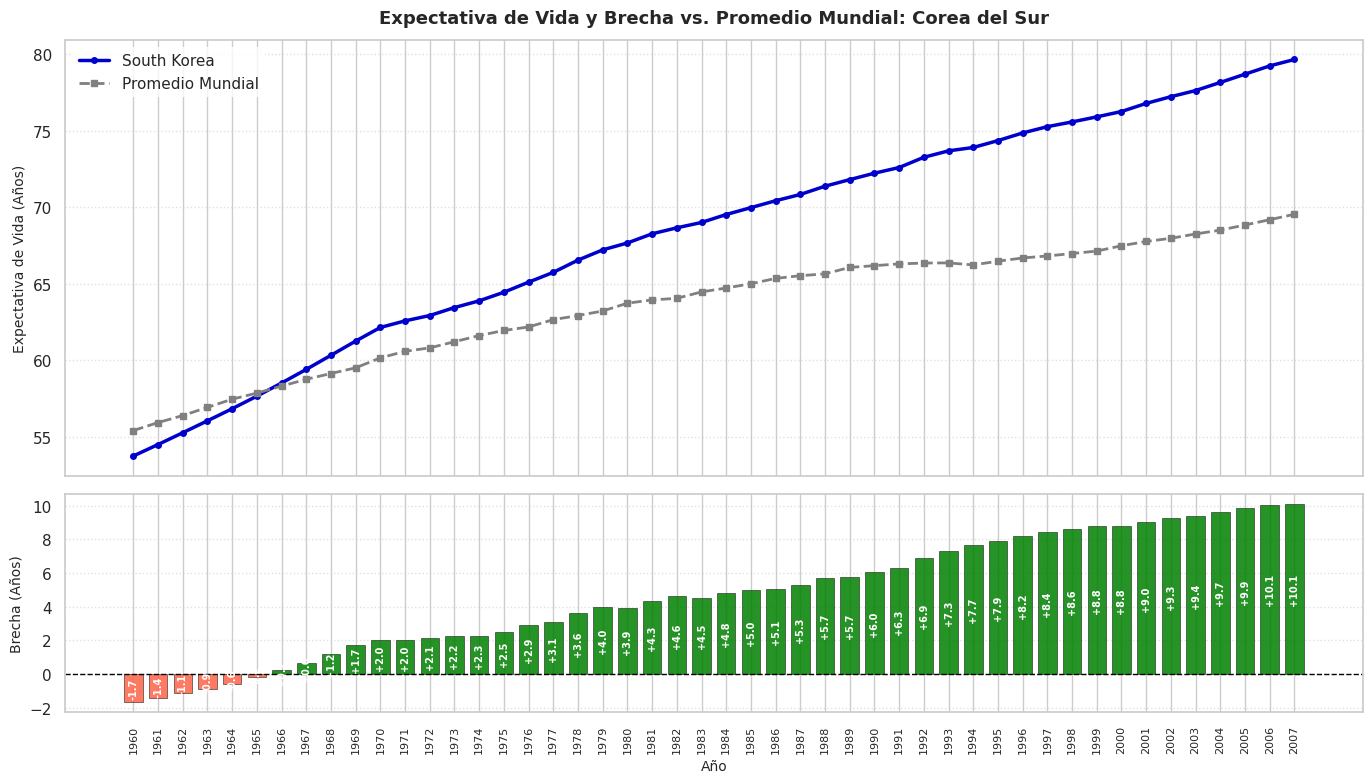

In [ ]:
# Convertimos la columna de años a string para las etiquetas del eje X
gap_pais['year_str'] = gap_pais['year'].astype(str)
n_años = len(gap_pais)
posiciones = np.arange(n_años)

# 1. Crear la figura con 2 subplots verticales compartiendo el eje X
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(14, 8),
    sharex=True,
    gridspec_kw={'height_ratios': [2, 1]}
)

# -------------------------------------------------------------
# Panel Superior: Líneas (País vs. Promedio Mundial)
# -------------------------------------------------------------
ax1.plot(posiciones, gap_pais['life_expectancy'],
         marker='o', markersize=4, linewidth=2.5, color='mediumblue', label=pais)

ax1.plot(posiciones, gap_pais['promedio_mundial'],
         marker='s', markersize=4, linewidth=2, linestyle='--',
         color='grey', label='Promedio Mundial')

ax1.set_title(f'Expectativa de Vida y Brecha vs. Promedio Mundial: Corea del Sur',
              fontsize=13, fontweight='bold', pad=12)
ax1.set_ylabel('Expectativa de Vida (Años)', fontsize=10)
ax1.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
ax1.grid(True, linestyle=':', alpha=0.6, axis='y')

# -------------------------------------------------------------
# Panel Inferior: Barras de Brecha (Verde / Rojo)
# -------------------------------------------------------------
# Asignación de color: Verde si la brecha es >= 0, Rojo si es < 0
colores = ['green' if b >= 0 else 'tomato' for b in gap_pais['brecha']]

bars = ax2.bar(posiciones, gap_pais['brecha'],
               color=colores, width=0.75, edgecolor='black',
               linewidth=0.4, alpha=0.85)

ax2.axhline(0, color='black', linewidth=1, linestyle='--')
ax2.set_ylabel('Brecha (Años)', fontsize=10)
ax2.set_xlabel('Año', fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.6, axis='y')

for bar in bars:
    val = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2, val / 2, f'{val:+.1f}',
             ha='center', va='center', rotation=90,
             fontsize=7, fontweight='bold', color='white')

# -------------------------------------------------------------
# Eje X: todos los años, rotados 90°
# -------------------------------------------------------------
ax2.set_xticks(posiciones)
ax2.set_xticklabels(gap_pais['year_str'], rotation=90)
ax2.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.show()


>El gráfico ilustra la mejora en la expectativa de vida durante el proceso que consolidó a Corea del Sur como uno de los Cuatro Tigres Asiáticos (junto a Taiwán, Hong Kong y Singapur). El país logró un crecimiento económico acelerado mediante un modelo de desarrollo tecnológico avanzado e industrialización orientada a las exportaciones.

##Pregunta B — Atipicidad

Países asiáticos en el dataset: 43
No encontrados: ['Taiwan']


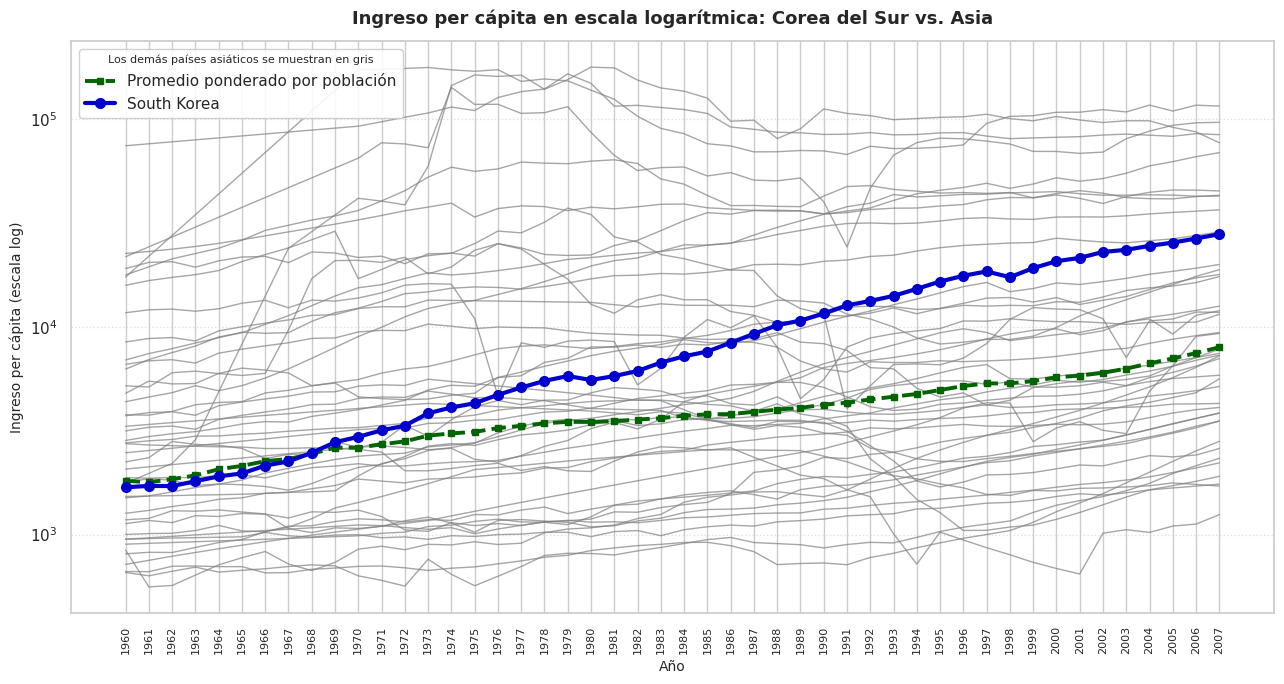

In [ ]:
col_variable  = 'income_per_person'
col_poblacion = 'population'
incluir_pais_en_promedio = True

# ── PAÍSES ASIÁTICOS ─────────────────────────────────────────────────────────
paises_asia = [
    # Este de Asia
    'China', 'Japan', 'South Korea', 'North Korea', 'Mongolia', 'Taiwan',
    # Sudeste asiático
    'Indonesia', 'Thailand', 'Vietnam', 'Philippines', 'Malaysia', 'Singapore',
    'Myanmar', 'Cambodia', 'Lao', 'Brunei', 'Timor-Leste',
    # Sur de Asia
    'India', 'Pakistan', 'Bangladesh', 'Sri Lanka', 'Nepal', 'Afghanistan',
    'Bhutan', 'Maldives',
    # Asia Central
    'Kazakhstan', 'Uzbekistan', 'Turkmenistan', 'Kyrgyz Republic', 'Tajikistan',
    # Asia Occidental / Medio Oriente
    'Turkey', 'Iran', 'Iraq', 'Saudi Arabia', 'Syria', 'Jordan', 'Lebanon',
    'Israel', 'Yemen', 'Oman', 'Kuwait', 'United Arab Emirates', 'Bahrain', 'Qatar',
]

presentes = [p for p in paises_asia if p in gap_filtrado['country'].unique()]
faltantes = [p for p in paises_asia if p not in gap_filtrado['country'].unique()]
print(f'Países asiáticos en el dataset: {len(presentes)}')
if faltantes:
    print(f'No encontrados: {faltantes}')

# ── 1. Series ────────────────────────────────────────────────────────────────
asia = gap_filtrado[gap_filtrado['country'].isin(presentes)]

serie_pais = (gap_filtrado[gap_filtrado['country'] == pais]
              .set_index('year')[col_variable])

if incluir_pais_en_promedio:
    base_promedio = asia
else:
    base_promedio = asia[asia['country'] != pais]

# Promedio continental ponderado por población
tmp = base_promedio.copy()
tmp['producto'] = tmp[col_variable] * tmp[col_poblacion]
agg = tmp.groupby('year')[['producto', col_poblacion]].sum()
serie_ponderada = agg['producto'] / agg[col_poblacion]

años = serie_ponderada.index

# ── 2. Gráfico ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 7))

#Países asiáticos
for nombre, sub in asia.groupby('country'):
    if nombre == pais:
        continue
    s = sub.set_index('year')[col_variable].reindex(años)
    ax.plot(años, s, color='grey', lw=1, alpha=0.7, zorder=1)

#Promedio ponderado
ax.plot(años, serie_ponderada.reindex(años), color='darkgreen', lw=2.8, ls='--',
        marker='s', markersize=5, label='Promedio ponderado por población', zorder=4)

#Corea del Sur
ax.plot(años, serie_pais.reindex(años), color='mediumblue', lw=3,
        marker='o', markersize=7, label=pais, zorder=5)

ax.set_yscale('log')
ax.set_title(f'Ingreso per cápita en escala logarítmica: Corea del Sur vs. Asia',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Ingreso per cápita (escala log)', fontsize=10)
ax.set_xlabel('Año', fontsize=10)
ax.set_xticks(años)
ax.set_xticklabels(años, rotation=90)
ax.tick_params(axis='x', labelsize=8)
ax.grid(True, linestyle=':', alpha=0.6, axis='y')
ax.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9,
          title='Los demás países asiáticos se muestran en gris', title_fontsize=8)

plt.tight_layout()
plt.show()

>El gráfico evidencia un **desarrollo atípico de Corea del Sur desde 1968 hasta el final de la serie en 2007**. Muestra una pendiente positiva en el ingreso per cápita (en escala logarítmica) que supera la pendiente correspondiente al promedio de Asia (ponderado por población). Esta ponderación es necesaria para evitar el efecto exagerado de países del Golfo o microestados como Brunéi que muestran altísimos ingresos per cápita e inflan el promedio.

Nota: Taiwán no está incluído en los datos.

   BRECHA DE COREA DEL SUR SOBRE EL PROMEDIO PONDERADO    
Año              País Promedio pond.     Brecha %
----------------------------------------------------------
1968            2,478        2,446         1.3%
1969            2,787        2,627         6.1%
1970            2,958        2,625        12.7%
1971            3,181        2,722        16.9%
1972            3,346        2,814        18.9%
1973            3,843        2,997        28.2%
1974            4,098        3,074        33.3%
1975            4,293        3,127        37.3%
1976            4,715        3,259        44.7%
1977            5,114        3,343        53.0%
1978            5,500        3,435        60.1%
1979            5,806        3,493        66.2%
1980            5,557        3,490        59.2%
1981            5,805        3,516        65.1%
1982            6,142        3,585        71.3%
1983            6,741        3,636        85.4%
1984            7,229        3,745        93.1%
1985            

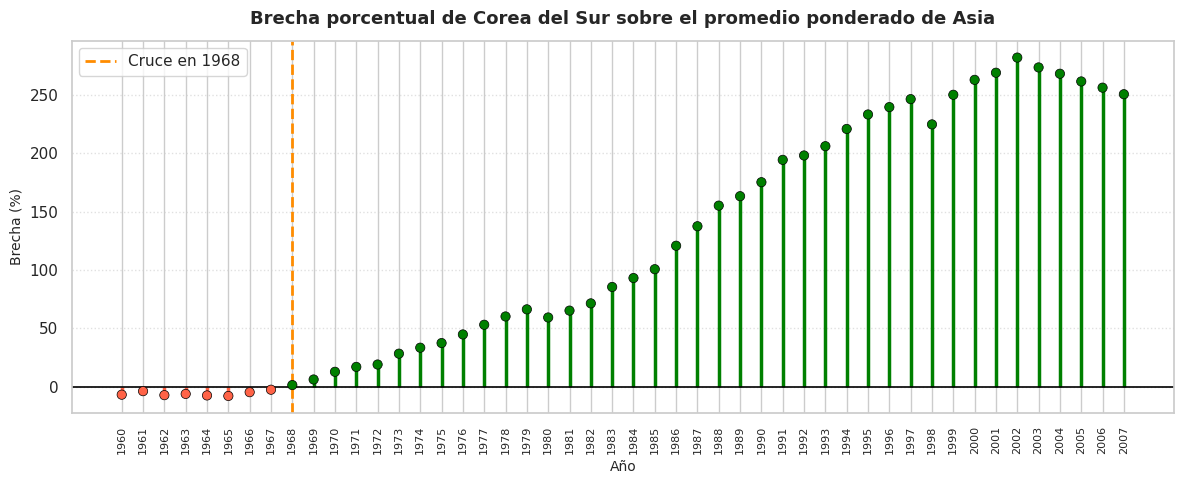

In [ ]:
# ── BRECHA EN % DESDE EL CRUCE HASTA EL ÚLTIMO AÑO ───────────────────────────
y_pais  = serie_pais.reindex(años)
y_bench = serie_ponderada.reindex(años)

# Brecha porcentual: cuánto más rico es el país que el promedio ponderado
brecha_pct = (y_pais / y_bench - 1) * 100

# Primer año en que el país supera el promedio de forma sostenida
supera = brecha_pct > 0
año_cruce = supera[supera].index[0] if supera.any() else None

if año_cruce is None:
    print(f'{pais} nunca supera el promedio ponderado en el período.')
else:
    tramo = brecha_pct.loc[año_cruce:]
    año_final = tramo.index[-1]

    print('=' * 58)
    print(f'BRECHA DE COREA DEL SUR SOBRE EL PROMEDIO PONDERADO'.center(58))
    print('=' * 58)
    print(f'{"Año":<8} {"País":>12} {"Promedio pond.":>12} {"Brecha %":>12}')
    print('-' * 58)
    for año in tramo.index:
        print(f'{año:<8} {y_pais[año]:>12,.0f} {y_bench[año]:>12,.0f} '
              f'{brecha_pct[año]:>11.1f}%')
    print('-' * 58)
    print(f'Año de cruce            : {año_cruce}')
    print(f'Duración del tramo      : {año_final - año_cruce} años ({año_cruce}–{año_final})')
    print(f'Brecha inicial          : {tramo.iloc[0]:.1f}%')
    print(f'Brecha final ({año_final})    : {tramo.iloc[-1]:.1f}%')
    print(f'Brecha promedio         : {tramo.mean():.1f}%')
    print(f'Brecha máxima           : {tramo.max():.1f}% en {tramo.idxmax()}')
    print('=' * 58)

    # ── Gráfico de la brecha ─────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5))

    colores_b = ['green' if v >= 0 else 'tomato' for v in brecha_pct]
    ax.vlines(años, 0, brecha_pct, colors=colores_b, lw=2.5)
    ax.scatter(años, brecha_pct, c=colores_b, s=45, edgecolor='black',
               linewidth=0.5, zorder=3)

    ax.axhline(0, color='black', lw=1.2)
    ax.axvline(año_cruce, color='darkorange', ls='--', lw=2,
               label=f'Cruce en {año_cruce}')

    ax.set_title(f'Brecha porcentual de Corea del Sur sobre el promedio ponderado de Asia',
                 fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel('Brecha (%)', fontsize=10)
    ax.set_xlabel('Año', fontsize=10)
    ax.set_xticks(años)
    ax.set_xticklabels(años, rotation=90, fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.6, axis='y')
    ax.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

> El gráfico muestra la brecha en ingreso per cápita entre Corea del Sur y el promedio ponderado de Asia. La magnitud de esta anomalía es considerable, ya que el país pasó de igualar el promedio ponderado continental a alcanzar **una brecha máxima de 282% en 2002**; en los 39 años que dura esta anomalía, **la brecha promedio fue de 143.6% del ingreso per cápita.**

> Luego de la recuperación posterior a **la Guerra de Corea (1950-1954)**, Corea del Sur implementó **un modelo de promoción de exportaciones que apalancó su desarrollo,** especialmente **desde la segunda mitad de la década de 1960.** La profundización de la brecha se condice con la **globalización económica** de las últimas dos décadas del siglo XX, y la caída en 1998 se debe al impacto de **la crisis financiera asiática** en Corea. Por último, la reducción de la brecha desde 2002 se explica por **el ingreso de China a la Organización Mundial de Comercio (OMC)** a fines de 2001, que marcó la inserción del gigante asiático en los mercados internacionales y el comienzo de un crecimiento acelerado, con tasas de dos dígitos por varios años.